In [1]:
# First import some necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn import mixture
up, down = True, False
np.set_printoptions(precision=3)
pd.set_option("expand_frame_repr", True)
pd.set_option("colheader_justify", "right")
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 500)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 75)
pd.set_option("display.precision", 4)

All import statements are provided for you- please do not import other libraries in your own code.

<a id='Topic0'></a>

# Assignment 1: Getting started with unsupervised learning

For the Module 1 programming assignment, you will focus on dimensionality reduction with PCA, using a music dataset of Spotify tracks.

Datasets often have a massive number of different features for each data point. In the case of the Spotify tracks dataset you will use, you will have features for each song, such as popularity, duration, and "loudness." Applications that utilize data like this - in this case, recommendation systems in music streaming apps - often need to reduce the number of features/dimensions to the data to make comparing each data point, or song in this case, computationally efficient. 

In this assignment, you will use PCA dimensionality reduction on a dataset of music tracks and look into some valuable tasks you can perform with the resulting PCA object. 

* First, you will create a PCA object on the song dataset and examine key attributes of the resulting object. 

* Second, with the PCA object you created in the first step, you will create a scree plot, which can help determine the number of principal components needed to account for an adequate amount of variance in the data.

* Third, you will use a biplot to visualize both the dataset and its features (variables), which will allow you to get insight into relationships between song features.

* Fourth, you will estimate a probability density over songs using kernel density estimation. This will allow you to glean interesting facts about songs and their relationships. In this step, you will compute the likelihood of songs in the dataset to see how ‘typical’ or ‘atypical’ they are in the dataset.

In [2]:
# Here, we read in the dataset and drop any tracks which might be missing values for a feature.

tracks_dataframe = pd.read_csv("./assets/tracks.csv")
tracks_dataframe = tracks_dataframe.dropna()

# Take a look at what's in the dataset!
tracks_dataframe.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,1.0100e-06,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,5.5600e-06,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.0000e+00,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Soundtrack),Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,7.0700e-05,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.0000e+00,0.0829,0.167,119.949,4,acoustic


In [3]:
# As you can see, Each track has features such as length, loudness, and speechiness. 
# We don't need every feature, so we're going to make a dataframe with only the features we want. 
feature_names = ["popularity","duration_ms","danceability","energy","key","loudness","speechiness","acousticness","liveness","tempo"]

# Here, we select only these features to simplify our dataset. Take a look at the new data!
tracks_dataframe = tracks_dataframe[feature_names]
tracks_dataframe.head()

,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,liveness,tempo
0,73,230666,0.676,0.4610,1,-6.746,0.1430,0.0322,0.3580,87.917
1,55,149610,0.420,0.1660,1,-17.235,0.0763,0.9240,0.1010,77.489
2,57,210826,0.438,0.3590,0,-9.734,0.0557,0.2100,0.1170,76.332
3,71,201933,0.266,0.0596,0,-18.515,0.0363,0.9050,0.1320,181.740
4,82,198853,0.618,0.4430,2,-9.681,0.0526,0.4690,0.0829,119.949


# Part 1: Using Principal Component Analysis (PCA)

In this part, we'll walk you through the process of creating and using a PCA object, and examine some key attributes of the resulting object. 

# Task 1a. Normalizing the dataset
(10 points)

The first step when preparing a dataset for PCA is to normalize the dataset. Conceptually, remember that what normalization does is to rescale the values of each feature (i.e. variable) so that the feature values have a mean of zero and a standard deviation of 1.

Using the `tracks_dataframe` dataset object provided above, complete the function below to return a numpy ndarray containing the normalized contents of the features in `tracks_dataframe`.

Hints:
 - Helpful Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
 - The two tools you need here are default StandardScaler and `.fit_transform()`
 

In [4]:
task_id = "1a"

In [5]:


def task_1a_solution():
    normalized_data = None
        
    # YOUR CODE HERE
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(tracks_dataframe)
    return normalized_data



In [6]:
# Use this cell to explore your solution.

task_1a_solution()

array([[ 1.783,  0.025,  0.629, ..., -0.85 ,  0.759, -1.142],
       [ 0.976, -0.731, -0.846, ...,  1.832, -0.591, -1.49 ],
       [ 1.065, -0.16 , -0.742, ..., -0.315, -0.507, -1.528],
       ...,
       [-0.504,  0.405,  0.358, ...,  1.66 , -0.681,  0.341],
       [ 0.348,  0.521,  0.116, ...,  0.199,  0.296,  0.461],
       [-0.504,  0.129, -0.235, ...,  1.101, -0.653, -1.433]])

In [7]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, np.ndarray
), f"Task {task_id}: Your function should return an np.ndarray. "

assert (
    stu_ans.shape[1] == 10
), f"Task {task_id}: Your returned ndarray has an incorrect number of columns. "

assert np.isclose(
    np.mean(stu_ans, axis=0), 0.0
).all(), (
    f"Task {task_id}: The columns of your returned ndarray should have a zero mean. "
)

assert np.isclose(
    np.std(stu_ans, axis=0), 1.0
).all(), (
    f"Task {task_id}: The columns of your returned ndarray should have a unit std. "
)


del stu_ans

Task 1a - AG tests
Task 1a - your answer:
[[ 1.783  0.025  0.629 ... -0.85   0.759 -1.142]
 [ 0.976 -0.731 -0.846 ...  1.832 -0.591 -1.49 ]
 [ 1.065 -0.16  -0.742 ... -0.315 -0.507 -1.528]
 ...
 [-0.504  0.405  0.358 ...  1.66  -0.681  0.341]
 [ 0.348  0.521  0.116 ...  0.199  0.296  0.461]
 [-0.504  0.129 -0.235 ...  1.101 -0.653 -1.433]]


# Task 1b: Creating the PCA object
(10 points)

Now, create a PCA object using the normalized data you produced in task 1a. 

For the arguments to PCA, be sure to use `n_components=6` and `random_state = 42`.

Helpful Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [8]:
task_id = '1b'


In [9]:
def task_1b_solution():
    normalized_data = task_1a_solution()
    
    # YOUR CODE HERE
    pca = PCA(n_components=6, random_state=42)
    pca.fit(normalized_data)
    return pca

In [10]:
# Use this cell to explore your solution.

task_1b_solution()

PCA(n_components=6, random_state=42)

In [11]:
#here are some tests which may help troubleshoot your answer.


print(f"Task {task_id} - AG tests")
stu_ans = task_1b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")


assert isinstance(
    stu_ans, PCA
), f"Task {task_id}: Your function should return a PCA object. "

assert (
    stu_ans.n_components == 6
), f"Task {task_id}: Your PCA object should be set to produce 6 components. "
assert stu_ans.components_.shape == (
    6,
    10,
), f"Task {task_id}: Your PCA fit on the grouped data should have produced 10 columns (one for each of the review_ features)."


del stu_ans

Task 1b - AG tests
Task 1b - your answer:
PCA(n_components=6, random_state=42)


<br>
Great! We now have our PCA object based on the song dataset. Now we're going to explore some neat things we can do with it. 

# Task 1c: Finding representative features for each principal component
(20 Points)

We know that each feature has a different weight in each principal component. 

Complete the function below to return, for each of the six principal components, the 3 features that have the highest absolute value weight for that principal component. This tells us which features "influence" that principal component the most.

- At a high level, this is what the function should do:
    - Get loading vectors for the principal components from the PCA object's .components_ attribute.
    - For each loading vector, 
    -    Take the biggest 3 absolute value feature weights and create a list of the corresponding 3 feature names
    -    Append this list of feature names to the final list of results.

    
- Hints: 
   - np.argsort() and np.abs() are useful for obtaining the indices of the highest feature weights in a loading.
   - Recall that you can use index into the `feature_names` list we created above to reference feature names. For example, if the third loading in the list has the highest absolute value weight, you can get the feature name with `feature_names[2]`.
   - You should append each list of 3 feature names to the end of the final "results" list. The list should be sorted from least to most weight (the last feature name in each list should have the highest weight) 
     


In [12]:
task_id = '1c'



In [13]:
def task_1c_solution():
    result = []
    pcaObject = task_1b_solution()
    # YOUR CODE HERE
    for loading in pcaObject.components_:
        top3_idx = np.argsort(np.abs(loading))[-3:]
        result.append([feature_names[i] for i in top3_idx])

    return (result)

In [14]:
# Use this cell to explore your solution.

task_1c_solution()

[['acousticness', 'loudness', 'energy'],
 ['danceability', 'speechiness', 'liveness'],
 ['speechiness', 'duration_ms', 'danceability'],
 ['duration_ms', 'popularity', 'key'],
 ['liveness', 'key', 'popularity'],
 ['key', 'duration_ms', 'tempo']]

In [15]:

print(f"Task {task_id} - AG tests")
stu_ans = task_1c_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")


assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list. "

assert (
    len(stu_ans) == 6
), f"Task {task_id}: Your function should return an list of length 6. "


# Some hidden tests

del stu_ans

Task 1c - AG tests
Task 1c - your answer:
[['acousticness', 'loudness', 'energy'], ['danceability', 'speechiness', 'liveness'], ['speechiness', 'duration_ms', 'danceability'], ['duration_ms', 'popularity', 'key'], ['liveness', 'key', 'popularity'], ['key', 'duration_ms', 'tempo']]


Take a look at the first 3 principal components. Think about how each component represents a certain aspect of a song. 

# Task 1d: Estimating total variance associated with principal components
(15 points)

We know that each Principal component accounts for a portion of the dataset's variance.

Complete the below function to return a value representing how much total variance the first five (5) principal components account for, using the PCA object you created in task 1b.

Hint: The explained_variance_ratio_ attribute of the PCA object is useful.

In [16]:
task_id = '1d'


In [17]:
def task_1d_solution():
    tracksPCAObject = task_1b_solution()
    cumulative_ratio = 0.0
    # YOUR CODE HERE
    cumulative_ratio = float(np.sum(tracksPCAObject.explained_variance_ratio_[:5]))
    return cumulative_ratio

In [18]:
# Use this cell to explore your solution.

task_1d_solution()

0.6988450870224975

In [19]:

print(f"Task {task_id} - AG tests")
stu_ans = task_1d_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float. "



del stu_ans

Task 1d - AG tests
Task 1d - your answer:
0.6988450870224975


# Task 2: Analyzing a scree plot
(5 points)

With the PCA object you created in task 1b, we can create a scree plot shown below, which can help us determine the number of principal components we need to select to account for an adequate amount of variance in the data.
We've also added a vertical line at eigenvalue 1.0 which will help you in this question.

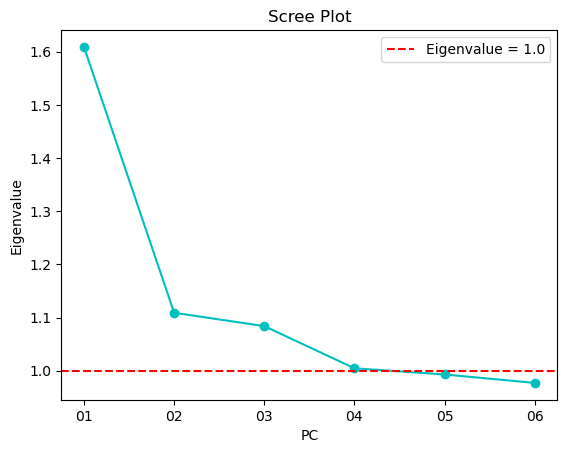

In [20]:

#Notice how we use normal explained_variance. You just used explained_variance_ratio_ in the previous part!

df = pd.DataFrame({'eigenvalue': np.sqrt(task_1b_solution().explained_variance_), 
                   'PC': ['01', '02', '03', '04', '05', '06']})

plt.plot(df['PC'], df['eigenvalue'], marker='o', color='c', linestyle='-')

plt.axhline(y=1.0, color='r', linestyle='--', label='Eigenvalue = 1.0')

plt.xlabel('PC')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')

plt.legend()

plt.show()


In [21]:
task_id = '2'

Based on the Kaiser heuristic, how many principal components should we use to get a good representation of the dataset?

The graph may be a bit too close to tell: try printing out the eigenvalues stored in `df`.

Put your answer as the return value in the function below:


In [22]:
df = pd.DataFrame({'eigenvalue': np.sqrt(task_1b_solution().explained_variance_), 
                   'PC': ['01', '02', '03', '04', '05', '06']})
print(df)

   eigenvalue  PC
0      1.6089  01
1      1.1090  02
2      1.0839  03
3      1.0046  04
4      0.9930  05
5      0.9771  06


In [23]:
def task_2_solution():
    solution = 4
    return solution

In [24]:

print(f"Task {task_id} - AG tests")
stu_ans = task_2_solution()

assert isinstance(
    stu_ans, int
), f"Task {task_id}: Your function should return a int. "


Task 2 - AG tests


# Part 3: Analyzing a biplot

Often, biplots are used to visualize PCA components. The code below uses the PCA object you created in part 1 to draw a biplot containing a scatterplot of the data and vectors corresponding to four of the dataset variables (song features). Run the cell below to create the graph. For each vector, the name of the corresponding variable is plotted near the end and slightly to the left of the end of the vector. In this part, you will answer questions about the biplot.

In [25]:
pca = task_1b_solution()
loadings = np.transpose(pca.components_[0:2, :])
for name, (x, y) in zip(feature_names, loadings):
    print(f"{name:15s} PC1={x:+.3f}  PC2={y:+.3f}")

popularity      PC1=-0.028  PC2=-0.201
duration_ms     PC1=-0.046  PC2=-0.089
danceability    PC1=-0.184  PC2=-0.255
energy          PC1=-0.573  PC2=+0.075
key             PC1=-0.051  PC2=-0.013
loudness        PC1=-0.539  PC2=-0.066
speechiness     PC1=-0.098  PC2=+0.598
acousticness    PC1=+0.521  PC2=+0.138
liveness        PC1=-0.097  PC2=+0.706
tempo           PC1=-0.226  PC2=-0.024


113999


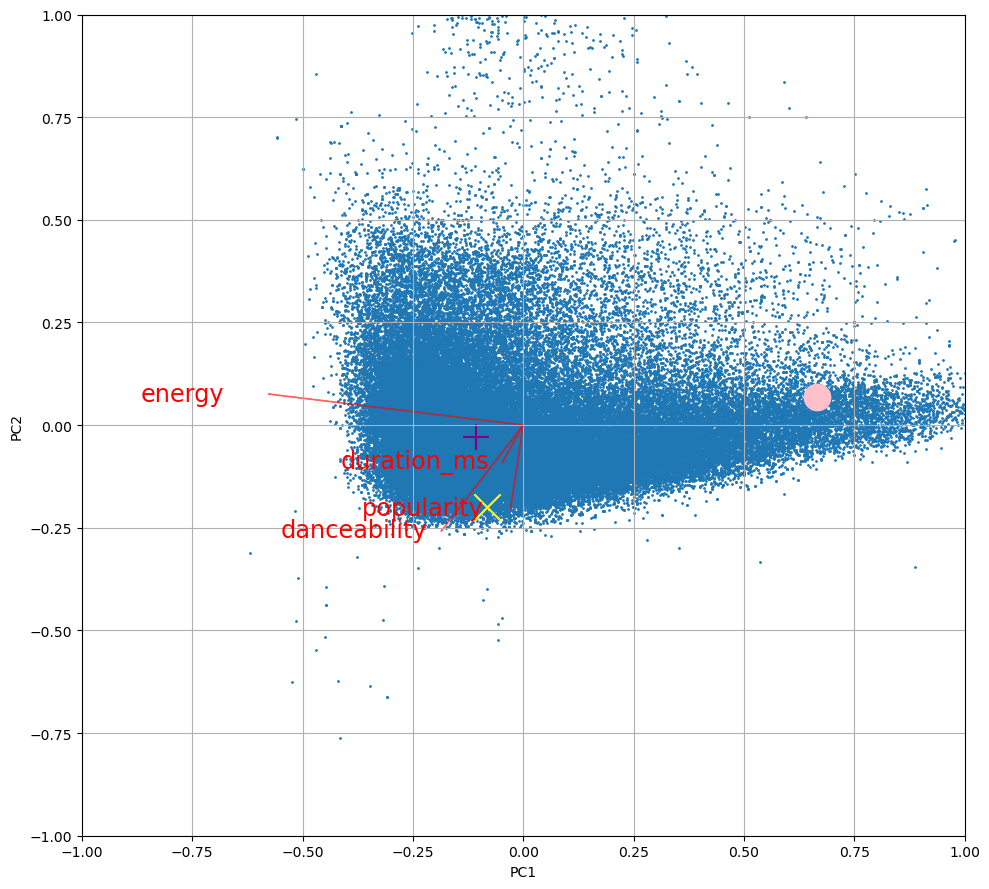

In [26]:


def biplot(score, coeff, maxdim, pcax, pcay, labels=None):
    """Routine to generate a high-quality biplot"""

    pca1 = pcax - 1
    pca2 = pcay - 1
    xs = score[:, pca1]
    ys = score[:, pca2]
    n = min(coeff.shape[0], maxdim)
    scalex = 2.0 / (xs.max() - xs.min())
    scaley = 2.0 / (ys.max() - ys.min())
    text_scale_factor = 1

    plt.figure(figsize=(10, 9))
    plt.scatter(xs * scalex, ys * scaley, s=1)
    xspecific = score[[20362, 103573, 76020], pca1]
    yspecific = score[[20362, 103573, 76020], pca2]
    ##xspecific = score[31:34, pca1]
    ##yspecific = score[31:34, pca2]
    plt.scatter(xspecific[0] * scalex, yspecific[0] * scaley, color='Yellow', marker='x', s=360)
    plt.scatter(xspecific[1] * scalex, yspecific[1] * scaley, color='Purple', marker='+', s=360)
    plt.scatter(xspecific[2] * scalex, yspecific[2] * scaley, color='Pink', marker='o', s=360)


    for i in range(n):
        plt.arrow(0, 0, coeff[i, pca1], coeff[i, pca2], color="r", alpha=0.5)
        if labels is None:
            plt.text(
                coeff[i, pca1] * text_scale_factor,
                coeff[i, pca2] * text_scale_factor,
                "Var" + str(i + 1),
                color="r",
                ha="center",
                va="center",
            )
        else:
            plt.text(
                coeff[i, pca1] * text_scale_factor - 0.2,
                coeff[i, pca2],
                labels[i],
                color="r",
                ha="center",
                va="center",
                size="xx-large"
            )
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xlabel("PC{}".format(pcax))
    plt.ylabel("PC{}".format(pcay))
    plt.grid()
    plt.tight_layout()
    return


def make_biplot():
    X_spotify_normalized = task_1a_solution()
    pca = task_1b_solution()
    X_spotify_pca = pca.transform(X_spotify_normalized)
    
    biplot(
        X_spotify_pca, np.transpose(pca.components_[0:2, :]), 4, 1, 2, labels=feature_names
    )
    print(len(X_spotify_pca))

    return

make_biplot()

# Task 3a: Biplot interpretation for variables
(10 points)

For the first task involving the biplot, answer the following questions: 


- What are the names of the two most correlated variables?
- What are the names of the two least correlated variables?

Populate the provided `most_correlated` and `least_correlated` lists with your solution. Order does not matter.

In [27]:
v = np.transpose(pca.components_[0:2, :])
best = None
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        cos = np.dot(v[i], v[j])/(np.linalg.norm(v[i])*np.linalg.norm(v[j]))
        ang = np.degrees(np.arccos(np.clip(cos,-1,1)))
        if best is None or abs(ang-90) < abs(best[0]-90):
            best = (ang, feature_names[i], feature_names[j])
print("closest to 90 degrees:", best)

closest to 90 degrees: (89.42769532979828, 'popularity', 'energy')


In [28]:
v = np.transpose(pca.components_[0:2, :])
rows = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        cos = np.dot(v[i], v[j])/(np.linalg.norm(v[i])*np.linalg.norm(v[j]))
        ang = np.degrees(np.arccos(np.clip(cos,-1,1)))
        rows.append((ang, feature_names[i], feature_names[j]))
rows.sort()
print("SMALLEST angles (most correlated):")
for r in rows[:5]:
    print(f"  {r[0]:6.1f}  {r[1]}, {r[2]}")
print("LARGEST angles (most anti-correlated):")
for r in rows[-5:]:
    print(f"  {r[0]:6.1f}  {r[1]}, {r[2]}")

SMALLEST angles (most correlated):
     0.9  loudness, tempo
     1.5  speechiness, liveness
     7.6  key, loudness
     8.4  duration_ms, danceability
     8.5  key, tempo
LARGEST angles (most anti-correlated):
   162.6  popularity, speechiness
   164.1  popularity, liveness
   171.3  acousticness, tempo
   172.1  loudness, acousticness
   179.8  key, acousticness


In [29]:
subset = ["popularity","duration_ms","danceability","energy"]
idx = [feature_names.index(s) for s in subset]
for a in range(len(idx)):
    for b in range(a+1, len(idx)):
        i, j = idx[a], idx[b]
        cos = np.dot(v[i], v[j])/(np.linalg.norm(v[i])*np.linalg.norm(v[j]))
        ang = np.degrees(np.arccos(np.clip(cos,-1,1)))
        print(f"  {ang:6.1f}  {feature_names[i]}, {feature_names[j]}")

    19.3  popularity, duration_ms
    27.7  popularity, danceability
    89.4  popularity, energy
     8.4  duration_ms, danceability
    70.1  duration_ms, energy
    61.7  danceability, energy


In [30]:
task_id = '3a'

In [31]:
def task_3a_solution():
    most_correlated = ["duration_ms", "danceability"]
    least_correlated = ["popularity", "energy"]
    return most_correlated, least_correlated

In [32]:

print(f"Task {task_id} - AG tests")
stu_ans = task_3a_solution()

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple. "

assert len(stu_ans) == 2, f"Task {task_id}: Your function should return a tuple of length 2."

for i, item in enumerate(stu_ans):
    assert isinstance(item, list), f"Task {task_id}: Element {i} of the tuple should be a list."
    assert len(item) == 2, f"Task {task_id}: List {i} should contain exactly two elements."
    for j, val in enumerate(item):
        assert isinstance(val, str), f"Task {task_id}: Element {j} in list {i} should be a string."


del stu_ans


Task 3a - AG tests


# Task 3b: Biplot interpretation for data points
(10 points)

You may have noticed that the biplot also shows three specially marked data points represented by a pink circle ("Pink"), a yellow X ("Yellow"), and a blue cross ("Blue"). Of these specially marked data points, one refers the popular pop song "Paris" by The Chainsmokers, another refers to a popular Spanish pop rock song, and a third refers to an old orchestral song. Thinking about the likely features of pop songs vs orchestral music, which of these specially marked points denotes the orchestral song? 

Submit your answer as the string 'Pink', 'Yellow', or 'Purple'.

In [33]:
task_id = '3b'

In [34]:
def task_3b_solution():
    ans = 'Pink'
    return ans

In [35]:
# Use this cell to explore your solution.

task_3b_solution()

'Pink'

In [36]:

print(f"Task {task_id} - AG tests")
stu_ans = task_3b_solution()

assert isinstance(
    stu_ans, str
), f"Task {task_id}: Your function should return a str. "


del stu_ans

Task 3b - AG tests


# Part 4: Kernel density estimation

Almost done! In the last part of this assignment, we will be using PCA components plotted in coordinate space with a kernel density object, which will allow us to glean insights about how rare or common specific types of songs are in the dataset. In this part, we will be computing how `typical` the orchestral song is compared to the other songs in the dataset. 

The code below is a helper function which will give us the first 2 principal components in coordinate format.


In [37]:
def get_PCA_coordinates():

    X_spotify_normalized = task_1a_solution()
    pca = task_1b_solution()
    X_spotify_pca = pca.transform(X_spotify_normalized)
    xs = X_spotify_pca[:, 0]
    ys = X_spotify_pca[:, 1]
    coordinates = np.column_stack((xs, ys))
    return coordinates

# Task 4a: Creating the kernel density object
(10 points)

The first step is to create the kernel density object. Create one using the coordinates from our helper function. 
Use 'gaussian' for the kernel argument in the KernelDensity object.

See the following documentation to see how to create the kernel density object: 
https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KernelDensity.html

Hint: We are going to be computing a density function over the coordinate points, so use `coordinates` as the input data used when fitting the KernelDensity object.

In [38]:
task_id = '4a'



In [39]:
def task_4a_solution():
    coordinates = get_PCA_coordinates()
    kde = None

    # YOUR CODE HERE
    kde = KernelDensity(kernel='gaussian')
    kde.fit(coordinates)

    return kde

In [40]:
# Use this cell to explore your solution.

task_4a_solution()

KernelDensity()

In [41]:

print(f"Task {task_id} - AG tests")
stu_ans = task_4a_solution()

assert isinstance(
    stu_ans, KernelDensity
), f"Task {task_id}: Your function should return a KernelDensity object. "


del stu_ans

Task 4a - AG tests


# Task 4b: Computing individual song likelihood
(10 points)

Now that we have the Kernel Density estimator object, we can calculate the likelihood of specific songs! Songs with high likelihood values are more typical in this dataset, while low likelihood songs are more unusual.  Return the *likelihood* of the orchestral song in the above biplot. 

- Hints:
  - The orchestral song is the 76020th element in the `coordinates` array.
  - kde.score_samples(in the kde documentation) and `np.exp` are useful here.  Remember that `score_samples` returns the log-likelihood of the input point(s).

For fun, you could also compute the likelihood of the other two songs visualized in Task 3b, which have indexes of 20362 and 103573 respectively, to see if they are more or less 'typical' than the orchestral example.

In [42]:
task_id = '4b'


In [43]:
def task_4b_solution():
    coordinates = get_PCA_coordinates()
    kde = task_4a_solution()

    probability = None
    # YOUR CODE HERE
    log_likelihood = kde.score_samples(coordinates[76020].reshape(1, -1))
    probability = float(np.exp(log_likelihood)[0])
    
    return probability

In [44]:
# Use this cell to explore your solution.

task_4b_solution()

0.00898288323383771

In [45]:
print(f"Task {task_id} - AG tests")
stu_ans = task_4b_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float "


del stu_ans

Task 4b - AG tests
Task 4b - your answer:
0.00898288323383771


# Bonus example: Gaussian mixture models for density estimation
Here is a Gaussian mixture model based on the first 2 principal components. Where do you think this orchestral song might be in this plot: close to the center or farther out?

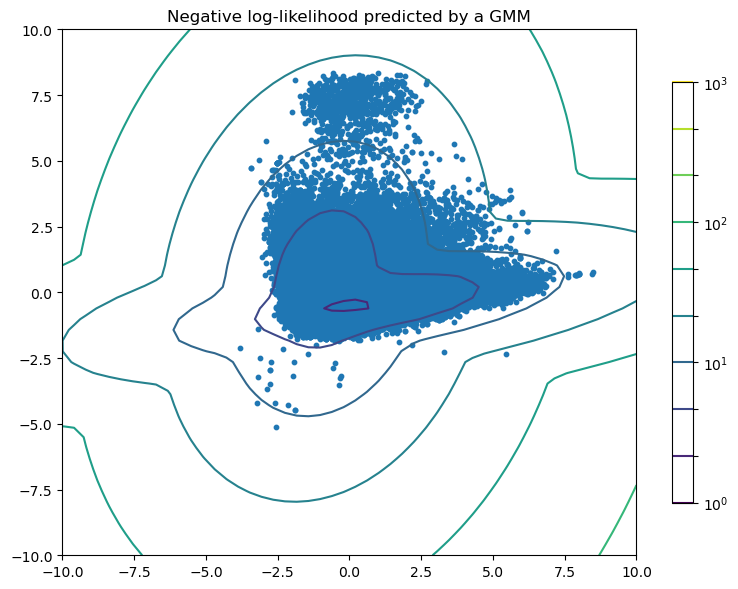

In [46]:
def GMM():
    X_spotify_normalized = task_1a_solution()
    pca = task_1b_solution()
    X_spotify_pca = pca.transform(X_spotify_normalized)
    xs = X_spotify_pca[:, 0]
    ys = X_spotify_pca[:, 1]
    coordinates = np.column_stack((xs, ys))
    clf = mixture.GaussianMixture(n_components=2, covariance_type='full')
    clf.fit(coordinates)
    x = np.linspace(-10.0, 10.0)
    y = np.linspace(-10.0,10.0)
    X, Y = np.meshgrid(x, y)
    XX = np.array([X.ravel(), Y.ravel()]).T
    Z = -clf.score_samples(XX)
    Z = Z.reshape(X.shape)
    plt.figure(figsize=(8, 6))
    plt.title("Negative log-likelihood predicted by a GMM")

    CS = plt.contour(
        X, Y, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10)
    )
    CB = plt.colorbar(CS, shrink=0.8)
    plt.scatter(coordinates[:, 0], coordinates[:, 1], 10)

    plt.tight_layout()

GMM()
